<h1>LSTM Analysis</h1>

<h2>Description</h2>
<p>Dataset can be downloaded at: </p>
<p>Features</p>

<h2>Environment Set-up</h2>

<p>If you try to run this notebook please substitute all the folder's path with yours or the code will not run </p>

In [1]:
import os
import sys
# Setting Hadoop home directory for the JVM
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-21.0.12"
os.environ["SPARK_HOME"] = r"C:\tools\Anaconda3\Lib\site-packages\pyspark"
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"] = (
    os.path.join(os.environ["JAVA_HOME"], "bin") + os.pathsep +
    os.path.join(os.environ["HADOOP_HOME"], "bin") + os.pathsep + 
    os.environ["PATH"]
    )

<p>Normally pyspark can work setting up Haddop and JAVA but while doing this analysis I found some problems and was necessary to do it.

The pyspark used in this analysis is the 4.2.0 so I recommend using a Hadood compatible to it, the one on this project folder is one of them.</p>

In [ ]:
import regex
#-------------------------------------------------------------------------------
# Data Manipulation Libraries
#-------------------------------------------------------------------------------
#Pandas : Used for data loading, manipulation, cleaning, and tabular data structures 
import pandas as pd
#-------------------------------------------------------------------------------
# Data Visualization Libraries
#-------------------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#-------------------------------------------------------------------------------
# Mathematical and Statistical Computing Libraries
#-------------------------------------------------------------------------------
import numpy as np
from scipy.stats import pearsonr

#-------------------------------------------------------------------------------
# Natural Language Processing Libraries
#-------------------------------------------------------------------------------
# NLTK: Natural Language Toolkit
import nltk
# English dictionary words and stopwords
from nltk.corpus import words, stopwords

from gensim.models import Word2Vec

#-------------------------------------------------------------------------------
# Feature Extraction and Teext Vectorization
#-------------------------------------------------------------------------------
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction import text 

#-------------------------------------------------------------------------------
# Topic Modelling
#-------------------------------------------------------------------------------
from sklearn.decomposition import LatentDirichletAllocation

#-------------------------------------------------------------------------------
# Machine Learning Models for Sentiment Classification.
#-------------------------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
import optuna
from tensorflow.keras.callbacks import Callback
#-------------------------------------------------------------------------------
# Model Evaluation Metrics Libraries
#-------------------------------------------------------------------------------
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix, f1_score

#-------------------------------------------------------------------------------
# Model Selection and ValidationLibraries
#-------------------------------------------------------------------------------
# GridSearchCV: Hyperparameter tuning using cross-validation
# StratifiedKFold: Preserves class distribution across folds
# Traain-Test Split: Splits dataset into training and testing subsets.
from sklearn.model_selection import train_test_split

#-------------------------------------------------------------------------------
# Notebook Visualization Settings
#-------------------------------------------------------------------------------
# Enables inline plotting in Jupyter notebooks.
%matplotlib inline

# Sets Seaborn dark theme for cleaner plots.
sns.set_style("darkgrid")
# Sets default color palette
sns.set_palette('husl',8)

##For users to install: wordclou and gensim optuna

In [ ]:
import findspark
findspark.init()
import pyspark
from pyspark.ml.feature import Tokenizer, CountVectorizer, StringIndexer
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, IntegerType
from pyspark.sql.window import Window
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql import SparkSession

spark =( SparkSession.builder
        .master("local[*]")
        .config('spark.hadoop.home.dir', r'C:\hadoop')
        .config('spark.jars.packages','org.postgresql:postgresql:42.7.12')
        .appName("LSTM Author Classification")
        .getOrCreate()
)
print('Spark Version:', spark.version)
print('Hadoop Home:', os.environ["HADOOP_HOME"])

Spark Version: 4.2.0
Hadoop Home: C:\hadoop


<h2>Data Extraction and Dataset Creation </h2>

In [4]:
# Set dataset path
# Copy the path from your dataset folder and past here or it wont work
DATASET_PATH = r"C:\Users\lab_services_student\Desktop\PDAN02_POE_PART_01\Authorship_TextAttribution\dataset"
# Read text file
raw_df = (spark.read.format('binaryFile')
          .option('recursiveFileLookup','true')
          .option('pathGlobalFilter','*.txt')
          .load(DATASET_PATH)
          .withColumn("content", F.expr("decode(content, 'UTF-8')"))
          .select("path", "content")
)

In [ ]:
# Parsing author and book name from file path
parsed_df =(
    raw_df
    .withColumn('normal_path',F.regexp_replace('path',r'\\','/'))
    .withColumn('author',F.regexp_extract(F.col("normal_path"), r'/dataset/([^/]+)/', 1))
    .withColumn('file_name',F.regexp_extract(F.col("normal_path"), r'/([^/]+)$', 1))
    .withColumn('book_name',F.regexp_replace(F.col("file_name"), r'\.[^.]+$', ""))
    .filter(F.col('author')!="")
    .filter(F.col("content").isNotNull())
    
)

In [6]:
# Setting up Chunk Size - Earch Row will have 200 words
chunk_size = 200
# Split text into words
words_df = (
    parsed_df
    .withColumn("words",F.split(
        F.trim(F.regexp_replace(F.col("content"), r"\s+"," ")), " ")
    )
    .filter(F.size(F.col("words")) >= chunk_size)
)

In [7]:
# Create non-overlapping chunks of 200 words
df = (
    words_df
    .withColumn("starts",
            F.sequence(
                F.lit(0),
                F.size(F.col("words")) - chunk_size,
                F.lit(chunk_size)
            )
    )
    .withColumn("chunks",
                F.transform(
                    F.col("starts"),
                    lambda s: F.array_join(F.slice(F.col('words'), s + 1, chunk_size), " ")
                )
    )
    .select("author","book_name", F.explode("chunks").alias("text"))
    .filter(F.length(F.trim(F.col("text"))) > 0)
)

In [8]:
# Displaying Spark Dataframe
df.printSchema()
df.show(5, truncate=120)

root
 |-- author: string (nullable = true)
 |-- book_name: string (nullable = true)
 |-- text: string (nullable = true)

+-----------+-------------+------------------------------------------------------------------------------------------------------------------------+
|     author|    book_name|                                                                                                                    text|
+-----------+-------------+------------------------------------------------------------------------------------------------------------------------+
|Leo Tolstoy|War and Peace|An Anonymous Volunteer, and David Widger WAR AND PEACE By Leo Tolstoy/Tolstoi CONTENTS BOOK ONE: 1805 CHAPTER I CHAPT...|
|Leo Tolstoy|War and Peace|CHAPTER II CHAPTER III CHAPTER IV CHAPTER V CHAPTER VI CHAPTER VII CHAPTER VIII CHAPTER IX CHAPTER X CHAPTER XI CHAPT...|
|Leo Tolstoy|War and Peace|CHAPTER X CHAPTER XI CHAPTER XII CHAPTER XIII CHAPTER XIV CHAPTER XV CHAPTER XVI CHAPTER XVII CHAPTER XVIII

<p>The dataframe was created sucessfully! This will mark the end of this phase and the I will start the next phase.</p>

In [9]:
# Saving Dataframe as CSV
#df.write.mode("overwrite").option('header', True).csv(r"C:\Users\lab_services_student\Desktop\PDAN02_POE_PART_01\Authorship_TextAttribution\dataset\authors.csv")

<h2>Exlporatory Data Analysis</h2>

<h3>Dataset Inspection</h3>

In [10]:
df.count()

44949

<p>The dataset has 44k entries which is more than the required (10k), it should also provide enough data for the models to perform well especially since Deep Learning models require a huge amount of data.</p>

In [11]:
# Checking for null values
count_null = df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns])
count_null.show()

+------+---------+----+
|author|book_name|text|
+------+---------+----+
|     0|        0|   0|
+------+---------+----+



<p>No null row found</p>

In [12]:
# Checking for empty chunks
empty_chunks = df.filter(F.col("text").isNull() | (F.trim(F.col("text")) == ""))
print(f"Empty chunks: {empty_chunks.count()}")

Empty chunks: 0


<p>No empty text row found!</p>

In [13]:
# Removing a duplicate rows
df = df.dropDuplicates(subset=["text"])
print(f"Number of rows after removing duplicates: {df.count()}")

Number of rows after removing duplicates: 44949


<p>After removing duplicated rows the shape remains the same meaning there were no duplicates in the dataframe.</p>

In [14]:
# Removing whitespace and special characters
df = df.withColumn("text", F.trim(F.regexp_replace(F.col("text"), r"r\s+", " ")))

In [ ]:
# Remving any redisual characters
df = df.withColumn("text", F.regexp_replace(F.col("text"), r"[^\x20-\x7E]", ""))

<h3>Class Balance</h3>

In [ ]:
# Count Chunks per Author
author_counts =(
    df.groupBy("author").agg(
    F.count("*").alias("num_chunks"),
    F.countDistinct("book_name").alias("num_books")
    )
    .orderBy(F.desc("num_chunks"))
)
author_counts.show(truncate=False)

#Compute imbalance ratio
counts_pd = author_counts.toPandas()
imbalance_ratio = counts_pd["num_chunks"].max() / counts_pd["num_chunks"].min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f}%")

+-------------------+----------+---------+
|author             |num_chunks|num_books|
+-------------------+----------+---------+
|Leo Tolstoy        |8526      |10       |
|Fyodor Dostoyevsky |7530      |10       |
|Jonathan Swift     |6209      |10       |
|Herman Melville    |6038      |10       |
|Nathaniel Hawthorne|5358      |10       |
|Jack London        |5329      |10       |
|Arthur Conan Doyle |3496      |10       |
|Bernard Shaw       |2463      |10       |
+-------------------+----------+---------+

Imbalance Ratio: 3.46


<p>It seams Tolstoy has the highest number of chunks with Dostonyvsky ckide ti wuth and the other authors close with each other, except for Conan Doyle and B. Shaw with a now number.

This balance raises the chance of the model not performing well with some authors compared to authors. </p>

<h3>Text Length and Vocabilary Statistics</h3>

In [18]:
# Calculate Text Length Statistics
length_stats = df.select(
    F.length("text").alias("char_count"),
    F.size(F.split("text", " ")).alias("word_count")
)

length_stats.select(
    F.mean("char_count").alias("main_chars"),
    F.stddev("char_count").alias("std_chars"),
    F.min("char_count").alias("min_chars"),
    F.max("char_count").alias("max_chars"),
    F.mean("word_count").alias("mean_words"),
    F.stddev("word_count").alias("std_words")
    
).show()

+-----------------+-----------------+---------+---------+----------+---------+
|       main_chars|        std_chars|min_chars|max_chars|mean_words|std_words|
+-----------------+-----------------+---------+---------+----------+---------+
|1106.216111593139|58.64878895693548|      874|     1440|     200.0|      0.0|
+-----------------+-----------------+---------+---------+----------+---------+



In [19]:
# Vocabulary size per author
#RegexTokenizer with lowecasing
tokemizer = Tokenizer(inputCol="text", outputCol="tokens")
df = tokemizer.transform(df)

df = df.withColumn(
    "tokens",
        F.filter(
            F.flatten(
                F.transform("tokens",lambda x : F.split(F.regexp_replace(x, '([^a-zA-Z0-9])', ' $1 '), ' ')
                )
            ),
            lambda x :F.length(x) > 0 
        )
)
df = df.withColumn("tokens", F.transform("tokens", lambda w:F.lower(w)))
df.select("tokens").show(5, truncate=80)

+--------------------------------------------------------------------------------+
|                                                                          tokens|
+--------------------------------------------------------------------------------+
|[always, became, specially, keen, when, he, had, to, guide, a, young, man, an...|
|[of, pultsk, ,, which, is, considered, a, great, victory, but, in, my, opinio...|
|[to, release, them, from, the, land, bank, ,, but, would, probably, neve, eve...|
|[usual, formalities, he, left, the, lodge, and, went, home, ., chapter, viii,...|
|[the, middle, of, the, ballroom, to, sing, ,, but, with, quite, a, different,...|
+--------------------------------------------------------------------------------+
only showing top 5 rows


In [20]:
voc_per_author = (df
                  .select("author",F.explode("tokens").alias("word"))
                  .groupBy("author")
                  .agg(F.countDistinct("word").alias("vocab_size"))
                  .orderBy(F.desc("vocab_size"))
)
voc_per_author.show(truncate=False)

+-------------------+----------+
|author             |vocab_size|
+-------------------+----------+
|Herman Melville    |39984     |
|Jonathan Swift     |33927     |
|Leo Tolstoy        |32564     |
|Jack London        |31543     |
|Nathaniel Hawthorne|28265     |
|Fyodor Dostoyevsky |26967     |
|Arthur Conan Doyle |22027     |
|Bernard Shaw       |21965     |
+-------------------+----------+



In [21]:
global_vocab = (df.select(F.explode("tokens").alias("word"))
               .distinct()
               .count()
)
print(f"Global vocabulary size = {global_vocab}")

Global vocabulary size = 89231


<h3>Data Visualisation<h3>

<h4>Word Cloud</h4>

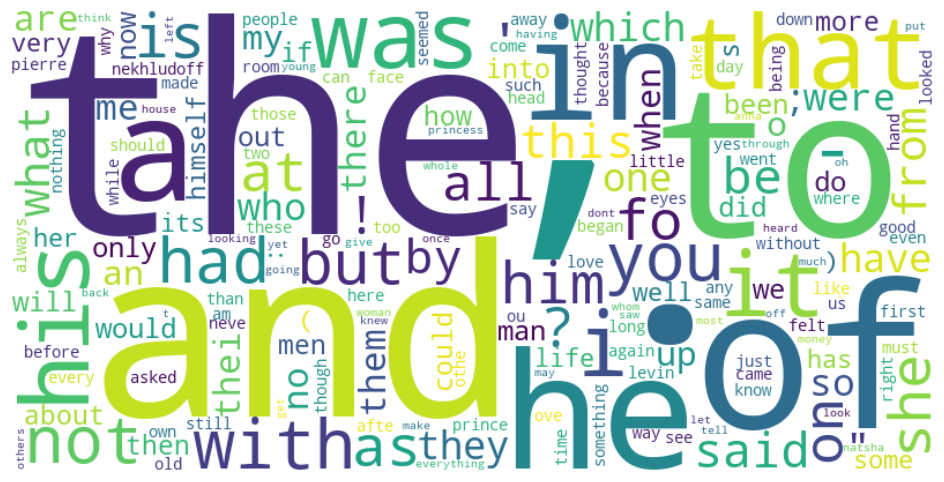

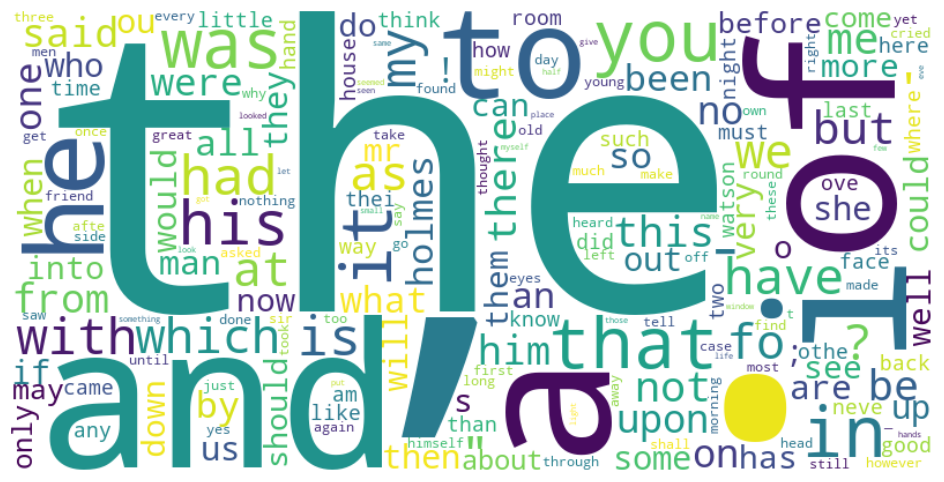

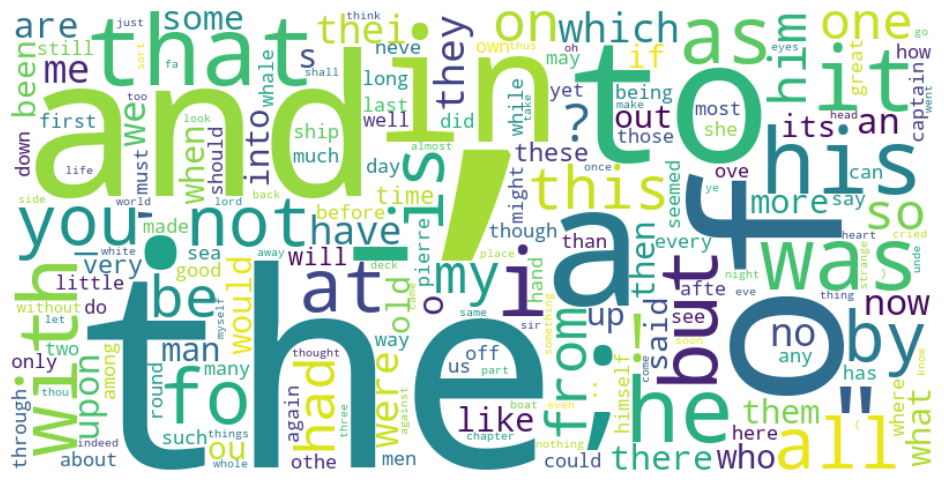

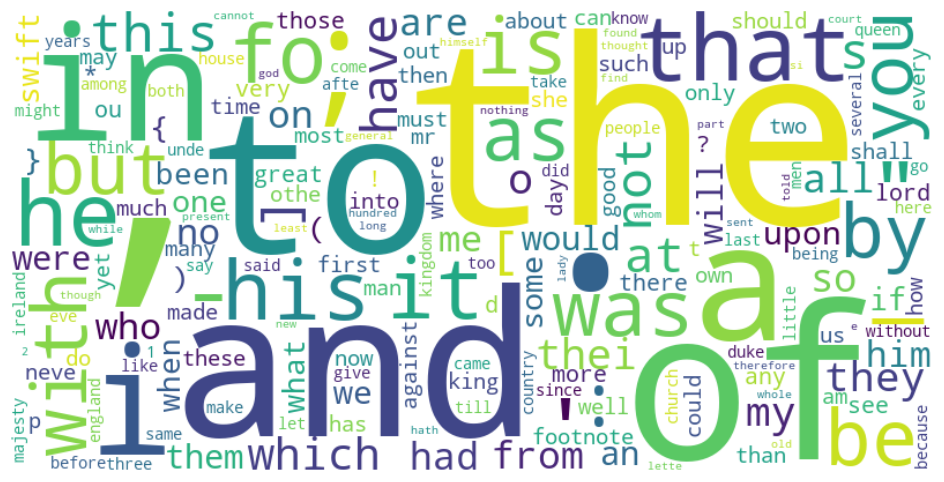

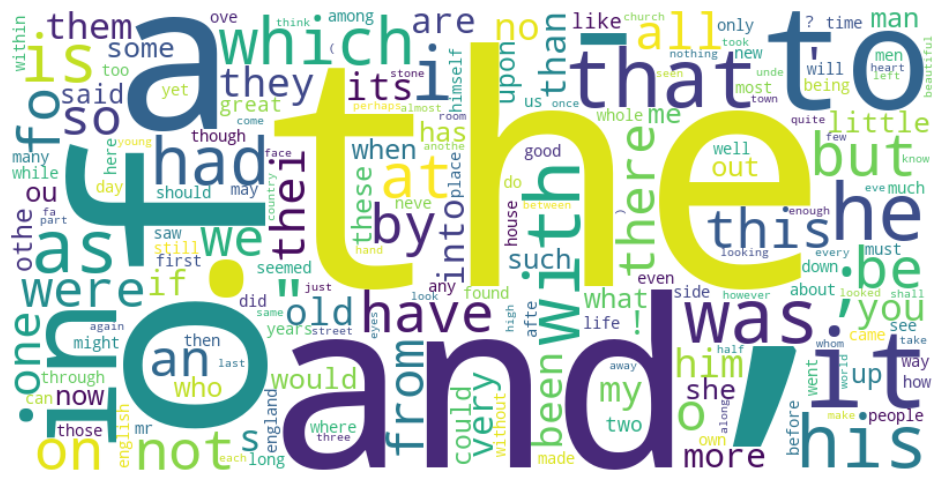

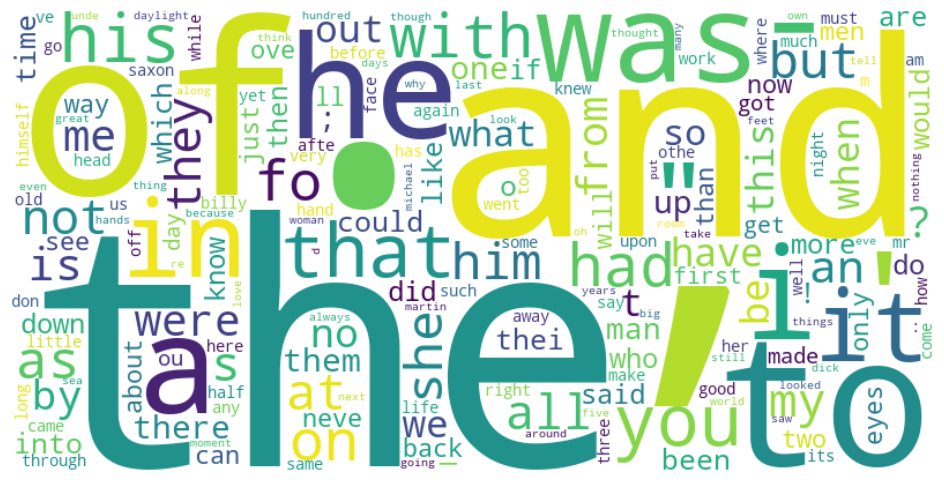

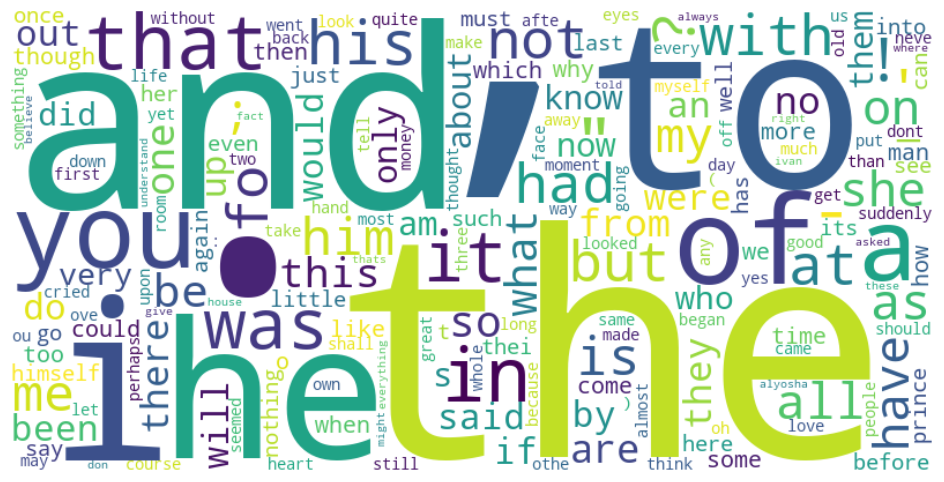

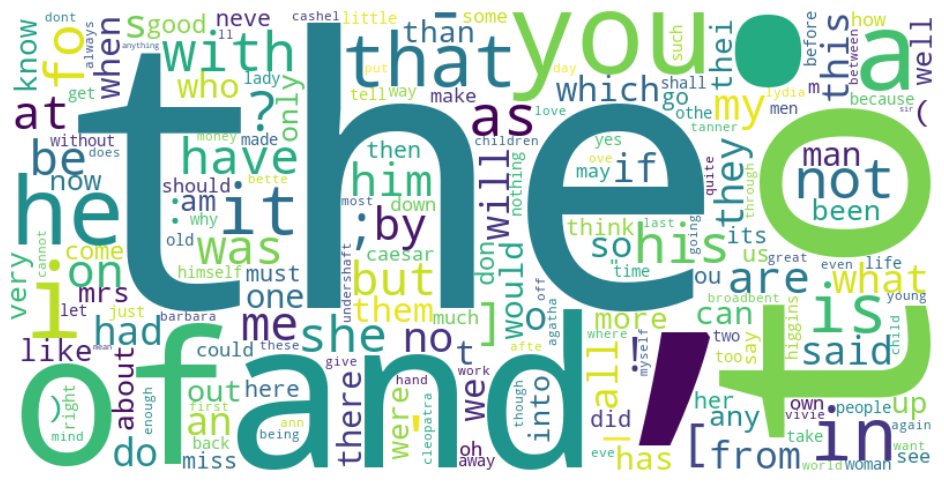

In [22]:
authors = [row["author"] for row in df.select("author").distinct().collect()]
for author in authors:
    # Aggregate word frequencies for top 200 words
    freq_df = (
        df
        .filter(F.col("author") == author)
        .select(F.explode("tokens").alias("word"))
        .groupBy("word").count()
        .orderBy(F.desc("count"))
        .limit(200)
        .toPandas()
    )
    freq_dict = dict(zip(freq_df["word"], freq_df["count"]))
    wcloud = WordCloud(width=800,height=400,background_color="white").generate_from_frequencies(freq_dict)

    plt.figure(figsize=(12,6))
    plt.imshow(wcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

<h3>Box Plots and Histograms</h3>

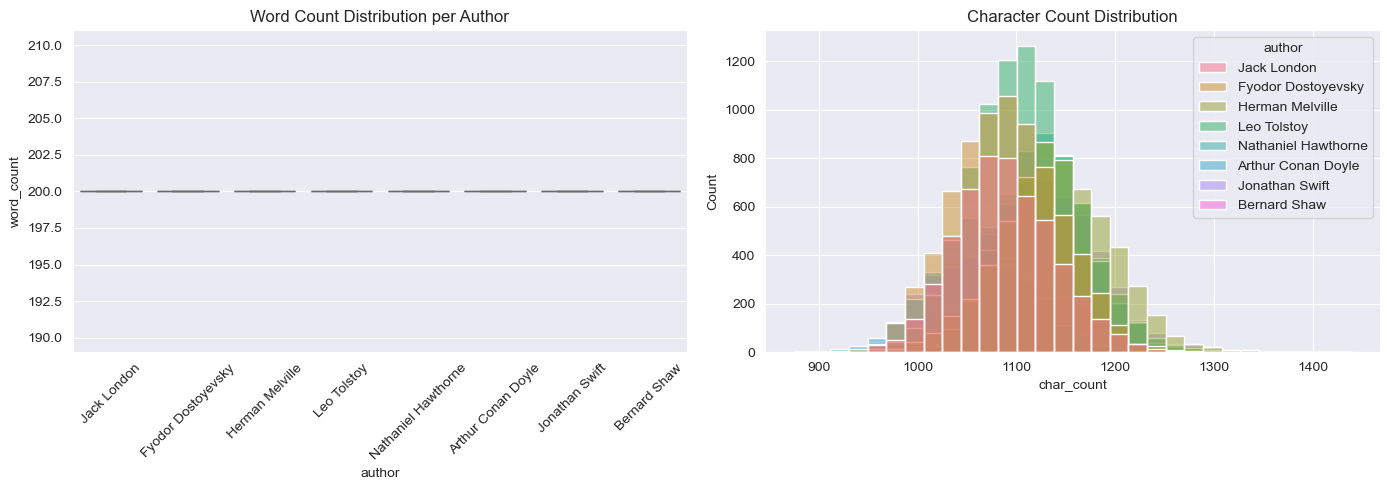

In [23]:
length_pd = (df
             .withColumn("char_count", F.length("text"))
             .withColumn("word_count", F.size(F.split("text", " ")))
             .select("author", "char_count", "word_count")
             .toPandas()
)

fig, axes =plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=length_pd, x="author", y="word_count", ax=axes[0])
axes[0].set_title("Word Count Distribution per Author")
axes[0].tick_params(axis="x", rotation=45)

sns.histplot(data=length_pd, x="char_count",hue="author", bins=30, ax=axes[1])
axes[1].set_title("Character Count Distribution")
plt.tight_layout()
plt.show()

<h3>PCA and t-SNE</h3>

In [24]:
#Training a Word2Vec
sentences = [row["tokens"] for row in df.select("tokens").collect()]
word2vec = Word2Vec(vector_size=100,min_count=5,sentences=sentences,seed=42, workers=4)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [25]:
#Broadcast word to vector map
wv = word2vec.wv
vector_size = wv.vector_size
word_to_vec = {w: Vectors.dense(wv[w].tolist()) for w in wv.index_to_key}
bc_map = spark.sparkContext.broadcast(word_to_vec)

In [26]:
# UDF tokens to array vectors
@F.udf(ArrayType(VectorUDT()))
def tokens_to_vectors(tokens):
    m = bc_map.value
    return [m[t] for t in tokens if t in m]
tokenized_df = df.withColumn("word_vectors", tokens_to_vectors(F.col("tokens")))

In [27]:
# Convert array vectors to mean vector
@F.udf(VectorUDT())
def avg_vectors(vectors):
    if not vectors:
        return Vectors.dense([0.0]*vector_size)
    arr = np.array([v.toArray() for v in vectors])

    return Vectors.dense(arr.mean(axis=0).tolist())

#Getting Document Embeddings
doc_emb_df = tokenized_df.withColumn("doc_vector", avg_vectors(F.col("word_vectors")))

In [28]:
# Converting to Pandas for data visualization
emb_pd = doc_emb_df.select("author","doc_vector").toPandas()
X = np.vstack(emb_pd["doc_vector"].apply(lambda v: v.toArray()).values)
Y = emb_pd["author"].values

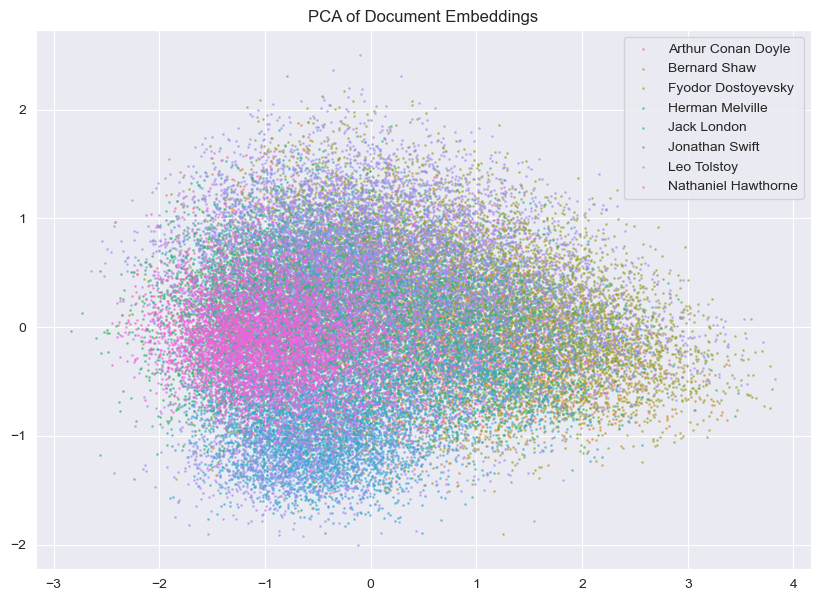

In [63]:
# Computing PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
for author in np.unique(Y):
    mask = Y == author
    plt.scatter(X_pca[mask,0], X_pca[mask, 1], label=author, alpha=0.5, s=1.0)

plt.legend()
plt.title("PCA of Document Embeddings")
plt.show()

In [64]:
# Computing TSNE
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X)
plt.figure(figsize=(10,7))
for author in np.unique(Y):
    mask = Y == author
    plt.scatter(X_tsne[mask,0], X_tsne[mask, 1], label=author, alpha=0.5, s=1.0)
    
plt.legend()
plt.title("t-SNE of Document Embeddings")
plt.show()

KeyboardInterrupt: 

<h2>Feature Selectiona and Engineering</h2>

In [31]:
#Building a vocabulary with Index Mapping
vocab_df = (
    df
    .select(F.explode("tokens").alias("word"))
    .groupBy("word").count()
    .filter(F.col("count") >= 5)
)
# Assigning integer index to each word
vocab_df = vocab_df.withColumn("word_id", F.row_number().over(Window.orderBy(F.desc("count"))).cast("int"))

#Calculating vocabularu size
max_id = vocab_df.agg(F.max("word_id")).collect()[0][0]
vocab_size = int(max_id)+1
print(f"Vocabulary size : {vocab_size}")

Vocabulary size : 35908


<h3>GloVe Embedding Matrix</h3>

In [32]:
# Loading GolVe vectors
glove_schema = "word string, " + ", ".join([f"v{i} float" for i in range(300)])
# Do not forget to puth model path here
glove_df = spark.read.csv(r"C:\Users\lab_services_student\Desktop\PDAN02_POE_PART_01\Authorship_TextAttribution\glove.6B.300d.txt", sep=" ", schema=glove_schema)

In [33]:
# Joining vocabularu with GloVe
vocab_glove = vocab_df.join(glove_df, on="word", how="left")
# Count coverage
coverage = vocab_glove.filter(F.col("v0").isNotNull()).count()
g_avg = coverage/vocab_size
g_avg_pct = 100*coverage/vocab_size
print(f"Glove Coverage: {g_avg} ({g_avg_pct:.1f}%) ")

Glove Coverage: 0.891834688648769 (89.2%) 


In [34]:
# Collecting embedding matrix to driver
#Sorting by word_id to get correct index order
vocab_glv_sorted = vocab_glove.orderBy("word_id").toPandas()
np.random.seed(42)
embedding_matrix = np.zeros((vocab_size, 300), dtype=np.float32)

for i, row, in vocab_glv_sorted.iterrows():
    wid = int(row["word_id"])
    if pd.notna(row["v0"]):

        embedding_matrix[wid] = row[[f"v{i}" for i in range(300)]].values.astype(np.float32)
        
    else:
        # OOV: random normal initialisation
        embedding_matrix[wid] = np.random.normal(0, 0.05, 300).astype(np.float32)

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: (35908, 300)


<h3>Converting Tokens to Index Sequences</h3>

In [35]:
word_to_id = {row["word"]: row["word_id"] for row in vocab_df.collect()}

#UDF to map tokens to indeces
def tokens_to_ids(tokens):
    return [int(word_to_id.get(t, 0)) for t in tokens] # 0 = <UNK> or <PAD>

tokens_to_ids_udf = F.udf(tokens_to_ids, ArrayType(IntegerType()))
# Functon to Pad or Truncate SEQ_LEN = 200

SEQ_LEN=200
def pad_or_truncate(ids, seq_len=SEQ_LEN):
    if len(ids) >= seq_len:
        return ids[:seq_len]
    return ids + [0] * (seq_len - len(ids))

pad_udf = F.udf(pad_or_truncate, ArrayType(IntegerType()))

df = (
    df
    .withColumn("tokens_ids", tokens_to_ids_udf(F.col("tokens")))
    .withColumn("sequence", pad_udf(F.col("tokens_ids")))
)
df.select("author","book_name","sequence").show(5, truncate=80)

+------------------+-----------------------------------+--------------------------------------------------------------------------------+
|            author|                          book_name|                                                                        sequence|
+------------------+-----------------------------------+--------------------------------------------------------------------------------+
|       Jack London|   The Little Lady of the Big House|[19, 7, 531, 1, 61, 15, 560, 1, 19, 813, 208, 64, 3, 19, 7, 531, 63, 5, 2, 79...|
|Fyodor Dostoyevsky|                      Short Stories|[19, 260, 50, 3474, 1, 19, 10, 56, 1, 19, 12, 61, 8, 23, 4154, 6, 1029, 9, 2,...|
|   Herman Melville|Mardi and A Voyage Thither, Vol. II|[19, 11871, 6, 170, 1, 13, 14, 35, 989, 12, 48, 87, 0, 1, 46, 35088, 1, 6261,...|
|Fyodor Dostoyevsky|     White Nights and Other Stories|[19, 69, 15, 79, 49, 43, 51, 3178, 32, 19, 40, 217, 1, 223, 72, 36, 155, 17, ...|
|   Herman Melville|         Pierr

<h3>Author Label Encoding</h3>

In [36]:
label_indexer = StringIndexer(inputCol="author", outputCol="author_index", handleInvalid="skip")
label_model = label_indexer.fit(df)
df = label_model.transform(df)
#Saving label mapping
label_map = df.select("author","author_index").distinct().orderBy("author_index").toPandas()
print(label_map)
NUM_AUTHORS = label_map.shape[0]

                author  author_index
0          Leo Tolstoy           0.0
1   Fyodor Dostoyevsky           1.0
2       Jonathan Swift           2.0
3      Herman Melville           3.0
4  Nathaniel Hawthorne           4.0
5          Jack London           5.0
6   Arthur Conan Doyle           6.0
7         Bernard Shaw           7.0


<h2>Model Trainng</h2>

<h3>Data Splitting</h3>

In [37]:
# Gettin unique values
books_df = df.select("author","book_name").distinct()
# Splitting data for each author
# Splitting books in 70/10/20 -> training/validation/test
train_books, val_books, test_books = [], [], []
for row in books_df.groupBy("author").agg(F.collect_list("book_name").alias("books")).collect():
    author = row["author"]
    books = sorted(row["books"])
    
    n = len(books)
    n_train = max(1, int((0.7*n)))
    n_val = max(1,int(0.1*n)) if n >= 3 else 0
    n_test = n - n_train - n_val
    
    if n == 1:
        train_books.append((author, books[0]))
        
    elif n == 2:
        train_books.append((author, books[0]))
        test_books.append((author, books[1]))
        
    else:
        for b in books[:n_train]:
            train_books.append((author, b))
        
        for b in books[n_train:n_train + n_val]:
            val_books.append((author, b))
        
        for b in books[n_train + n_val:]:
            test_books.append((author, b))

In [38]:
# Creating DataFrames
train_books_df = spark.createDataFrame(train_books, ["author", "book_name"])
val_books_df = spark.createDataFrame(val_books, ["author", "book_name"])
test_books_df = spark.createDataFrame(test_books, ["author", "book_name"])

train_df = df.join(train_books_df, on=["author","book_name"], how="inner")
val_df = df.join(val_books_df, on=["author","book_name"], how="inner")
test_df = df.join(test_books_df, on=["author","book_name"], how="inner")

print(f"Train: {train_df.count()} chunks")
print(f"Validation: {val_df.count()} chunks")
print(f"Test: {test_df.count()} chunks")

Train: 32613 chunks
Validation: 4540 chunks
Test: 7796 chunks


In [39]:
# Checking author balance
for name, df in [("Train",train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n--- {name} ---")
    df.groupBy("author").count().orderBy("author").show(truncate=False)


--- Train ---
+-------------------+-----+
|author             |count|
+-------------------+-----+
|Arthur Conan Doyle |2432 |
|Bernard Shaw       |1912 |
|Fyodor Dostoyevsky |5173 |
|Herman Melville    |4378 |
|Jack London        |3400 |
|Jonathan Swift     |4225 |
|Leo Tolstoy        |7270 |
|Nathaniel Hawthorne|3823 |
+-------------------+-----+


--- Val ---
+-------------------+-----+
|author             |count|
+-------------------+-----+
|Arthur Conan Doyle |562  |
|Bernard Shaw       |185  |
|Fyodor Dostoyevsky |1268 |
|Herman Melville    |397  |
|Jack London        |568  |
|Jonathan Swift     |610  |
|Leo Tolstoy        |532  |
|Nathaniel Hawthorne|418  |
+-------------------+-----+


--- Test ---
+-------------------+-----+
|author             |count|
+-------------------+-----+
|Arthur Conan Doyle |502  |
|Bernard Shaw       |366  |
|Fyodor Dostoyevsky |1089 |
|Herman Melville    |1263 |
|Jack London        |1361 |
|Jonathan Swift     |1374 |
|Leo Tolstoy        |724  |
|Nat

In [40]:
def macro_f1(y_true, y_pred):
    #y_true: (batch,) integer labels
    #y_pred: (batch, num_classes) softmax probabilities
    y_pred = K.cast(K.argmax(y_pred, axis=1), "int32")
    y_true = K.cast(K.reshape(y_true, (-1,)), "int32")
    
    f1s = []
    
    for c in range(NUM_AUTHORS):
        tp = K.sum(K.cast((y_true == c) & (y_pred == c), "float32"))
        fp = K.sum(K.cast((y_true != c) & (y_pred == c), "float32"))
        fn = K.sum(K.cast((y_true == c) & (y_pred != c), "float32"))
        precision = tp/(tp + fp + K.epsilon())
        recall = tp/(tp + fn + K.epsilon())
        f1 = 2*precision*recall/(precision+recall+K.epsilon())
        f1s.append(f1)
    return K.mean(K.stack(f1s))

In [53]:
# Callback that calcuates sklearn macro-F1 on val set
class MacroF1Callback(Callback):
    def __init__(self, x_val, y_val, name="val_macro_f1"):
        super().__init__()
        self.x_val = x_val
        self.y_val = y_val
        self.name = name
    
    def on_epoch_end(self, epoch, logs=None):
        logs =logs if logs is not None else {}
        y_pred = self.model.predict(self.x_val, verbose=0).argmax(axis=1)
        logs[self.name] = f1_score(self.y_val, y_pred, average="macro")

<h3>Training: Simple Model</h3>

In [47]:
#Converting Dataframes to Pandas Dataframes
train_pd = train_df.select("Sequence", "author_index").toPandas()
val_pd = val_df.select("Sequence", "author_index").toPandas()
test_pd = test_df.select("Sequence", "author_index").toPandas()
# Creating X and Y variables
X_train = np.vstack(train_pd["Sequence"].apply(lambda x: np.array(x)).values)
Y_train = train_pd["author_index"].values.astype("int32")

X_val= np.vstack(val_pd["Sequence"].apply(lambda x: np.array(x)).values)
Y_val = val_pd["author_index"].values.astype("int32")

X_test = np.vstack(test_pd["Sequence"].apply(lambda x: np.array(x)).values)
Y_test = test_pd["author_index"].values.astype("int32")

In [ ]:
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=300,
        weights=[embedding_matrix],
        input_length=SEQ_LEN,
        trainable=True
    ),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(NUM_AUTHORS, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy", macro_f1])
model.summary()

c:\tools\Anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    10,772,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,772,400 (41.09 MB)

 Trainable params: 10,772,400 (41.09 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
callbacks = [
    MacroF1Callback(X_val, Y_val),
    EarlyStopping(monitor="val_macro_f1", mode="max", patience=3,restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)

]
history = model.fit(X_train,Y_train, 
                    validation_data=(X_val, Y_val),
                    epochs=5, batch_size=64,
                    callbacks=callbacks)

Epoch 1/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 263s 516ms/step - accuracy: 0.9977 - loss: 0.0092 - macro_f1: 0.9941 - val_accuracy: 0.7925 - val_loss: 0.8254 - val_macro_f1: 0.7572 - learning_rate: 0.0010
Epoch 2/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 261s 512ms/step - accuracy: 0.9984 - loss: 0.0069 - macro_f1: 0.9946 - val_accuracy: 0.7846 - val_loss: 0.9395 - val_macro_f1: 0.7324 - learning_rate: 0.0010
Epoch 3/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 266s 522ms/step - accuracy: 0.9990 - loss: 0.0046 - macro_f1: 0.9962 - val_accuracy: 0.7722 - val_loss: 1.0857 - val_macro_f1: 0.7263 - learning_rate: 0.0010
Epoch 4/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 270s 529ms/step - accuracy: 0.9998 - loss: 0.0014 - macro_f1: 0.9968 - val_accuracy: 0.7903 - val_loss: 1.0222 - val_macro_f1: 0.7480 - learning_rate: 5.0000e-04


In [55]:
print("History Keys: ", list(history.history.keys()))

History Keys:  ['accuracy', 'loss', 'macro_f1', 'val_accuracy', 'val_loss', 'val_macro_f1', 'learning_rate']


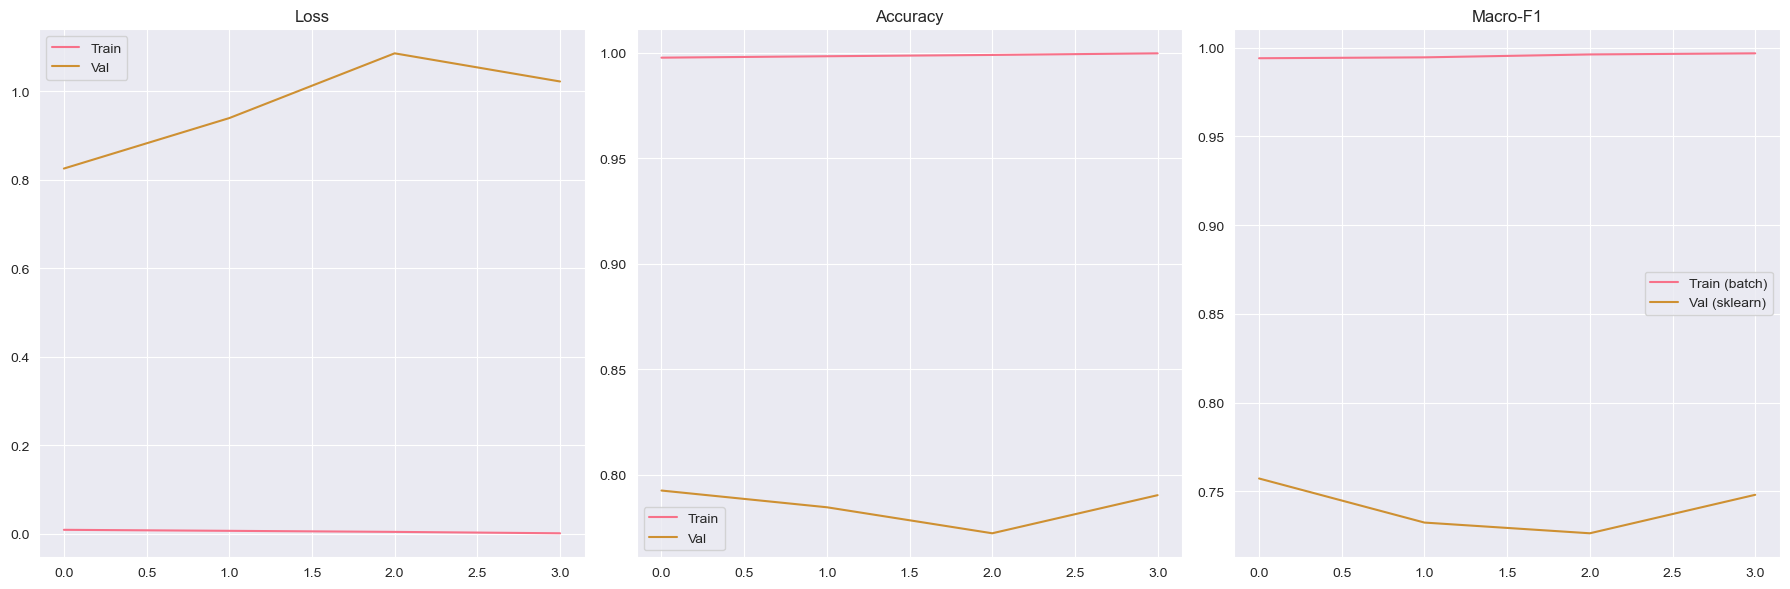

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train")
axes[1].plot(history.history["val_accuracy"], label="Val")
axes[1].set_title("Accuracy")
axes[1].legend()

axes[2].plot(history.history["macro_f1"], label="Train (batch)")
axes[2].plot(history.history["val_macro_f1"], label="Val (sklearn)")
axes[2].set_title("Macro-F1")
axes[2].legend()

plt.tight_layout()
plt.show()

<h3>Model Optimisation</h3>

In [61]:
def build_model(trial):
    emb_dim = trial.suggest_categorical("emb_dim", [100, 200, 300])
    hidden = trial.suggest_categorical("hidden_units", [120,256,300, 512])
    n_layers = trial.suggest_int("n_lstm_layers", 1, 2)
    emb_drop = trial.suggest_float("emb_dropout", 0.2, 0.5, step=0.1)
    lstm_drop = trial.suggest_float("lstm_dropout", 0.2, 0.4, step=0.1)
    lr = trial.suggest_categorical("learning_rate", [0.001, 0.01, 0.1])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    
    model = Sequential()
    # Using pre-trined GloVe only if emb_dim==300
    if emb_dim == 300:
        model.add(Embedding(vocab_size, emb_dim,weights=[embedding_matrix], trainable=True))
    else:
        model.add(Embedding(vocab_size, emb_dim, trainable=True))
    
    model.add(Dropout(emb_drop))

    for i in range(n_layers):
        return_seq = (i < n_layers-1)
        model.add(Bidirectional(LSTM(hidden, return_sequences=return_seq)))
        model.add(Dropout(lstm_drop))
    
    model.add(Dense(NUM_AUTHORS, activation="softmax"))
    
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=Adam(learning_rate=lr, clipnorm=1.0),
        metrics=["accuracy",macro_f1]
    )
    
    return model, batch_size

In [62]:
def objective(trial):
    model, batch_size = build_model(trial)
    
    callbacks = [
        EarlyStopping(monitor="val_macro_f1", mode="max", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
        MacroF1Callback(X_val, Y_val)
    ]
    
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=15,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )
    #Return best validaion loss
    return max(history.history["val_macro_f1"])

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print("Best Trial: ")
print(study.best_trial.params)
print(f"Best val loss: {study.best_trial.value}")

[I 2026-09-21 21:06:10,468] A new study created in memory with name: no-name-c7156a44-0142-48e7-9419-bcd24976e920
[I 2026-09-21 22:32:42,590] Trial 0 finished with value: 0.7500271994730536 and parameters: {'emb_dim': 300, 'hidden_units': 256, 'n_lstm_layers': 1, 'emb_dropout': 0.2, 'lstm_dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 32}. Best is trial 0 with value: 0.7500271994730536.
[W 2026-09-21 22:34:12,308] Trial 1 failed with parameters: {'emb_dim': 100, 'hidden_units': 300, 'n_lstm_layers': 2, 'emb_dropout': 0.30000000000000004, 'lstm_dropout': 0.4, 'learning_rate': 0.01, 'batch_size': 128} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\tools\Anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\lab_services_student\AppData\Local\Temp\ipykernel_15352\4224989889.py", line 10, in objective
    history = model.fit(
        X_train, Y_train,
    ..

KeyboardInterrupt: 

In [ ]:
# Getting best parameters
best_params = study.best_trial.params
# Getting best epochs
best_epochs = [
    t.user_attrs.get("best_epoch", 10)
    for t in study.trials if t.value is not None
]
n_epochs= int(np.median(best_epochs)) if best_epochs else 10
# Rebuilding model with best parameters
final_model, best_batch = build_model(optuna.trial.FixedTrial(best_params))

# Combining train and validation for the final training
X_final = np.vstack([X_train, X_val])
Y_final = np.concatenate([Y_train, Y_val])
# Splitting the dat
X_train, X_val, Y_train, Y_val = train_test_split(X_final,Y_final, test_size=0.1, stratify=Y_final, random_state=42)

callbacks =[
    MacroF1Callback(X_val,Y_val),
    EarlyStopping(monitor="val_macro_f1", mode="max", patience=3, restore_best_weights=True)
]



final_model.fit(X_train, Y_train,validation_data=(X_val, Y_val), epochs=n_epochs,  batch_size=best_batch,callbacks=callbacks, verbose=1)

<h3>Model Evaluation</h3>

In [ ]:
y_pred_proba = final_model.predict(X_test)
y_pred = y_pred_proba.argmax(axis=1)
author_names= label_map.sort_values("author_index")["author"].tolist()

print("="*60)
print("Classificatio Report")
print("="*60)
classification_report(Y_test, y_pred, target_names=author_names, digits=4)